# Grupo Bimbo — Prediccion de Demanda & Pre-Orden de Compra
**Entorno: Anaconda local en macOS**

**Outputs:**
- Pre-orden de compra para el Cliente X en la Semana Y
- Sugerencia de restock con cantidades por producto
- Dashboard visual + CSVs exportados
- `BimboDemandModel.mlpackage` listo para Xcode

---
## Indice
1. Entorno Anaconda — verificacion y dependencias
2. Configuracion de rutas y datos
3. Carga de datos (estratificada, 3 M filas)
4. Feature Engineering RAM-eficiente
5. Entrenamiento LightGBM
6. Funciones de prediccion
7. Pre-orden de compra
8. Sugerencia de restock
9. Output final
10. Exportar a Core ML (.mlpackage) para Xcode


## 1. Entorno Anaconda — Verificacion y Dependencias

In [1]:
# Verifica que estas en el entorno correcto antes de instalar nada.
# Desde terminal:  conda activate <tu_env>  →  jupyter notebook
import sys, platform
print(f'Python      : {sys.version}')
print(f'Ejecutable  : {sys.executable}')
print(f'Sistema     : {platform.system()} {platform.mac_ver()[0]}')
assert platform.system() == 'Darwin', 'Este notebook requiere macOS para exportar Core ML'
print('macOS detectado — Core ML export habilitado')


Python      : 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:22:19) [Clang 14.0.6 ]
Ejecutable  : /opt/homebrew/anaconda3/bin/python
Sistema     : Darwin 14.7.6
macOS detectado — Core ML export habilitado


In [2]:
# Instala las dependencias que falten en tu entorno conda.
# Si ya las tienes instaladas, esta celda es un no-op rapido.
import subprocess, sys

PKGS = {
    'lightgbm':     'lightgbm',
    'onnx':         'onnx',
    'onnxmltools':  'onnxmltools',
    'coremltools':  'coremltools',
    'scikit-learn': 'scikit-learn',
    'seaborn':      'seaborn',
}

for import_name, pip_name in PKGS.items():
    try:
        __import__(import_name.replace('-', '_'))
        print(f'  OK  {import_name}')
    except ImportError:
        print(f'  Instalando {pip_name} ...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', pip_name, '-q'], check=True)
        print(f'  OK  {pip_name} instalado')

print('Dependencias listas')


  OK  lightgbm
  OK  onnx
  OK  onnxmltools
  OK  coremltools
  Instalando scikit-learn ...
  OK  scikit-learn instalado
  OK  seaborn
Dependencias listas


## 2. Configuracion Global y Rutas

In [3]:
import gc, os, zipfile, warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import mean_squared_log_error

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')

# ================================================================
#  CONFIGURACION — ajusta estas rutas a tu Mac
# ================================================================

# Carpeta donde estan los CSVs de Kaggle (train.csv, producto_tabla.csv, etc.)
# Ejemplo: '/Users/tu_nombre/datasets/bimbo/'
DATA_DIR = Path('/Users/abrahamcastanedaquintero/tmp/BimboChallenge-iOSHack/Model/grupo-bimbo-inventory-demand')          # <-- CAMBIA ESTA RUTA si es necesario

# Carpeta de salida para CSVs, dashboard y el .mlpackage
OUT_DIR  = Path('/Users/abrahamcastanedaquintero/tmp/BimboChallenge-iOSHack/Model/grupo-bimbo-inventory-demand')
OUT_DIR.mkdir(exist_ok=True)

SEED    = 42
NROWS   = 3_000_000    # filas totales a cargar (estratificadas por semana)

DTYPES_TRAIN = {
    'Semana':            'int8',
    'Agencia_ID':        'int16',
    'Canal_ID':          'int8',
    'Ruta_SAK':          'int16',
    'Cliente_ID':        'int32',
    'Producto_ID':       'int16',
    'Venta_uni_hoy':     'int32',
    'Venta_hoy':         'float32',
    'Dev_uni_proxima':   'int32',
    'Dev_proxima':       'float32',
    'Demanda_uni_equil': 'int32',
}

def mem_mb(df): return df.memory_usage(deep=True).sum() / 1e6
def gc_collect(): gc.collect()

print(f'DATA_DIR : {DATA_DIR.resolve()}')
print(f'OUT_DIR  : {OUT_DIR.resolve()}')
assert DATA_DIR.exists(), f'No existe DATA_DIR: {DATA_DIR.resolve()}  — ajusta la ruta arriba'
print('Configuracion OK')


DATA_DIR : /Users/abrahamcastanedaquintero/tmp/BimboChallenge-iOSHack/Model/grupo-bimbo-inventory-demand
OUT_DIR  : /Users/abrahamcastanedaquintero/tmp/BimboChallenge-iOSHack/Model/grupo-bimbo-inventory-demand
Configuracion OK


## 3. Carga de Datos

In [4]:
# ── Descarga desde Kaggle (solo si train.csv no existe) ─────────────────
# Requiere: pip install kaggle  +  ~/.kaggle/kaggle.json con tu API key
# Descarga manual alternativa: https://www.kaggle.com/c/grupo-bimbo-inventory-demand/data

train_csv = DATA_DIR / 'train.csv'

if not train_csv.exists():
    print('train.csv no encontrado — intentando descarga con Kaggle API ...')
    kaggle_cfg = Path.home() / '.kaggle' / 'kaggle.json'
    assert kaggle_cfg.exists(), (
        f'Kaggle API key no encontrada en {kaggle_cfg}.\n'
        'Opciones:\n'
        '  1. Crea ~/.kaggle/kaggle.json con tu API key de https://www.kaggle.com/account\n'
        '  2. Descarga manualmente los CSVs en: https://www.kaggle.com/c/grupo-bimbo-inventory-demand/data\n'
        f'     y colocalos en: {DATA_DIR.resolve()}'
    )
    os.system(
        f'kaggle competitions download -c grupo-bimbo-inventory-demand -p {DATA_DIR}'
    )
    zip_main = DATA_DIR / 'grupo-bimbo-inventory-demand.zip'
    if zip_main.exists():
        os.system(f'unzip -o -q "{zip_main}" -d "{DATA_DIR}"')
    print('Descarga completada')
else:
    print(f'train.csv encontrado en {train_csv.resolve()}')

# Descomprimir CSVs internos si existen
for fname in DATA_DIR.iterdir():
    if fname.suffix == '.zip' and fname.stem.endswith('.csv'):
        cpath = DATA_DIR / fname.stem
        if not cpath.exists():
            print(f'  Descomprimiendo {fname.name} ...')
            with zipfile.ZipFile(fname, 'r') as zf:
                zf.extractall(DATA_DIR)

print('Archivos disponibles:')
for f in sorted(DATA_DIR.iterdir()):
    print(f'  {f.name:45s}  {f.stat().st_size/1e6:8.1f} MB')


train.csv encontrado en /Users/abrahamcastanedaquintero/tmp/BimboChallenge-iOSHack/Model/grupo-bimbo-inventory-demand/train.csv
Archivos disponibles:
  .DS_Store                                           0.0 MB
  BimboDemandModel.onnx                              17.9 MB
  cliente_tabla.csv                                  21.3 MB
  dashboard_c3967.png                                 0.2 MB
  feature_importance.png                              0.1 MB
  preorden_c3967_s10_20260505_0905.csv                0.0 MB
  preorden_c3967_s10_20260505_0918.csv                0.0 MB
  producto_tabla.csv                                  0.1 MB
  restock_c3967_s10_20260505_0905.csv                 0.0 MB
  restock_c3967_s10_20260505_0918.csv                 0.0 MB
  sample_submission.csv                              68.9 MB
  test.csv                                          251.1 MB
  town_state.csv                                      0.0 MB
  train.csv                                        3199.4

In [5]:
# ── Carga estratificada por semana ───────────────────────────────────────
# train.csv esta ordenado por semana: un nrows simple cargaria solo semana 3.
# Solucion: pasar 1 vez liviana para contar filas/semana, luego muestrear.

ROWS_PER_CHUNK = 500_000

print('Paso 1/2 — Contando distribucion de semanas ...')
semana_counts = {}
for chunk in pd.read_csv(
    DATA_DIR / 'train.csv',
    usecols=['Semana'], dtype={'Semana': 'int8'},
    chunksize=ROWS_PER_CHUNK
):
    for s, n in chunk['Semana'].value_counts().items():
        semana_counts[s] = semana_counts.get(s, 0) + n

n_semanas       = len(semana_counts)
rows_per_semana = max(1, NROWS // n_semanas)
print(f'  Semanas: {sorted(semana_counts.keys())}  |  filas/semana objetivo: {rows_per_semana:,}')

print('Paso 2/2 — Cargando muestra estratificada ...')
chunks_sel    = []
semana_budget = {s: rows_per_semana for s in semana_counts}

for chunk in pd.read_csv(
    DATA_DIR / 'train.csv',
    dtype=DTYPES_TRAIN,
    chunksize=ROWS_PER_CHUNK
):
    parts = []
    for s, grp in chunk.groupby('Semana'):
        rem  = semana_budget.get(s, 0)
        if rem <= 0: continue
        take = min(len(grp), rem)
        parts.append(grp.sample(n=take, random_state=SEED) if take < len(grp) else grp)
        semana_budget[s] = rem - take
    if parts:
        chunks_sel.append(pd.concat(parts, ignore_index=True))
    if all(v <= 0 for v in semana_budget.values()):
        break

train = pd.concat(chunks_sel, ignore_index=True)
del chunks_sel; gc_collect()

assert train['Semana'].nunique() >= 2, 'Solo 1 semana cargada — aumenta NROWS'

print(f'  Shape  : {train.shape}  |  RAM: {mem_mb(train):.1f} MB')
print(f'  Semanas: {sorted(train["Semana"].unique())}')
print(f'  Clientes : {train["Cliente_ID"].nunique():,}  |  Productos: {train["Producto_ID"].nunique():,}')

productos = pd.read_csv(DATA_DIR / 'producto_tabla.csv')
clientes  = pd.read_csv(DATA_DIR / 'cliente_tabla.csv')
productos['Producto_ID'] = productos['Producto_ID'].astype('int16')
clientes['Cliente_ID']   = clientes['Cliente_ID'].astype('int32')
print('Datos cargados')


Paso 1/2 — Contando distribucion de semanas ...
  Semanas: [3, 4, 5, 6, 7, 8, 9]  |  filas/semana objetivo: 428,571
Paso 2/2 — Cargando muestra estratificada ...
  Shape  : (2999997, 11)  |  RAM: 96.0 MB
  Semanas: [3, 4, 5, 6, 7, 8, 9]
  Clientes : 54,408  |  Productos: 573
Datos cargados


## 4. Feature Engineering RAM-Eficiente
- Operaciones **in-place** para evitar copias
- Todo en **float32** (mitad de RAM vs float64)
- Tablas de agregacion precalculadas **una sola vez**


In [6]:
def build_agg_lookup_tables(df):
    agg_tables = {}
    groupings = {
        'mean_prod':         ['Producto_ID'],
        'mean_cliente':      ['Cliente_ID'],
        'mean_ruta':         ['Ruta_SAK'],
        'mean_agencia':      ['Agencia_ID'],
        'mean_canal':        ['Canal_ID'],
        'mean_prod_cliente': ['Producto_ID', 'Cliente_ID'],
        'mean_prod_ruta':    ['Producto_ID', 'Ruta_SAK'],
        'mean_prod_agencia': ['Producto_ID', 'Agencia_ID'],
    }
    target = 'Demanda_uni_equil'
    for feat, keys in groupings.items():
        tbl = (df.groupby(keys)[target]
                 .agg(['mean','std','median'])
                 .rename(columns={'mean': feat, 'std': feat+'_std', 'median': feat+'_med'})
                 .astype('float32').reset_index())
        agg_tables[feat] = tbl

    agg_tables['dev_rate'] = (
        df.groupby('Producto_ID')
          .apply(lambda x: x['Dev_uni_proxima'].sum() / x['Venta_uni_hoy'].clip(1).sum(),
                 include_groups=False)
          .rename('dev_rate_prod').astype('float32').reset_index()
    )
    agg_tables['venta_stats'] = (
        df.groupby('Producto_ID')[['Venta_uni_hoy','Dev_uni_proxima']]
          .median()
          .rename(columns={'Venta_uni_hoy':'med_venta_prod','Dev_uni_proxima':'med_dev_prod'})
          .astype('float32').reset_index()
    )
    agg_tables['seasonality'] = (
        df.groupby(['Semana','Producto_ID'])[target]
          .mean().rename('mean_semana_prod').astype('float32').reset_index()
    )
    return agg_tables


def apply_agg_features(df, agg_tables, global_mean):
    groupings = {
        'mean_prod':         ['Producto_ID'],
        'mean_cliente':      ['Cliente_ID'],
        'mean_ruta':         ['Ruta_SAK'],
        'mean_agencia':      ['Agencia_ID'],
        'mean_canal':        ['Canal_ID'],
        'mean_prod_cliente': ['Producto_ID','Cliente_ID'],
        'mean_prod_ruta':    ['Producto_ID','Ruta_SAK'],
        'mean_prod_agencia': ['Producto_ID','Agencia_ID'],
    }
    for feat, keys in groupings.items():
        df = df.merge(agg_tables[feat], on=keys, how='left')
    df = df.merge(agg_tables['dev_rate'],    on='Producto_ID', how='left')
    df = df.merge(agg_tables['venta_stats'], on='Producto_ID', how='left')
    df = df.merge(agg_tables['seasonality'], on=['Semana','Producto_ID'], how='left')

    fill_cols = [
        c for c in df.columns
        if c.startswith('mean_') or c.startswith('roll_') or
           c in ('dev_rate_prod','med_venta_prod','med_dev_prod',
                 'trend_1_2','growth_rate','lag_1','lag_2','lag_3',
                 'roll_mean_3','roll_mean_5','roll_std_3')
    ]
    fill_val = np.float32(global_mean)
    for c in fill_cols:
        if df[c].dtype != np.float32:
            df[c] = df[c].astype('float32')
        df[c].fillna(fill_val, inplace=True)
    return df


def compute_lag_features_inplace(df):
    df.sort_values(['Cliente_ID','Producto_ID','Semana'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    grp = df.groupby(['Cliente_ID','Producto_ID'])['Demanda_uni_equil']
    df['lag_1'] = grp.shift(1).astype('float32')
    df['lag_2'] = grp.shift(2).astype('float32')
    df['lag_3'] = grp.shift(3).astype('float32')
    shifted = grp.shift(1)
    df['roll_mean_3'] = shifted.transform(lambda x: x.rolling(3, min_periods=1).mean()).astype('float32')
    df['roll_mean_5'] = shifted.transform(lambda x: x.rolling(5, min_periods=1).mean()).astype('float32')
    df['roll_std_3']  = shifted.transform(lambda x: x.rolling(3, min_periods=1).std()).astype('float32')
    del shifted; gc_collect()
    df['trend_1_2']   = (df['lag_1'] - df['lag_2']).astype('float32')
    df['growth_rate'] = (df['lag_1'] / df['lag_2'].replace(0, np.nan)).clip(0,10).astype('float32')
    return df


print('Paso 1/3 — Tablas de agregacion ...')
GLOBAL_MEAN = float(train['Demanda_uni_equil'].mean())
agg_tables  = build_agg_lookup_tables(train)
gc_collect()

print('Paso 2/3 — Lag features (in-place) ...')
train = compute_lag_features_inplace(train)
gc_collect()

print('Paso 3/3 — Features de agregacion ...')
train = apply_agg_features(train, agg_tables, GLOBAL_MEAN)
gc_collect()

TARGET      = 'Demanda_uni_equil'
NON_FEATURES = {TARGET,'Venta_uni_hoy','Venta_hoy','Dev_uni_proxima','Dev_proxima'}
FEATURES    = [c for c in train.columns if c not in NON_FEATURES]

print(f'Feature engineering completo  |  {len(FEATURES)} features  |  RAM: {mem_mb(train):.1f} MB')


Paso 1/3 — Tablas de agregacion ...
Paso 2/3 — Lag features (in-place) ...
Paso 3/3 — Features de agregacion ...
Feature engineering completo  |  42 features  |  RAM: 528.0 MB


## 5. Entrenamiento LightGBM

In [7]:
semanas  = sorted(train['Semana'].unique())
n_sem    = len(semanas)
print(f'Semanas disponibles: {semanas}')

if n_sem >= 2:
    val_week   = semanas[-1]
    mask_val   = train['Semana'] == val_week
    mask_train = ~mask_val
    split_mode = f'temporal (val = semana {val_week})'
else:
    val_week   = semanas[0]
    rng        = np.random.default_rng(SEED)
    mask_val   = pd.Series(rng.random(len(train)) > 0.8, index=train.index)
    mask_train = ~mask_val
    split_mode = 'aleatorio 80/20 (solo 1 semana — revisa la carga)'

X_train = train.loc[mask_train, FEATURES]
y_train = np.log1p(train.loc[mask_train, TARGET].clip(0)).astype('float32')
X_val   = train.loc[mask_val,   FEATURES]
y_val   = np.log1p(train.loc[mask_val,   TARGET].clip(0)).astype('float32')

assert len(X_train) > 0, 'X_train vacio'
assert len(X_val)   > 0, 'X_val vacio'

print(f'Split    : {split_mode}')
print(f'Train    : {len(X_train):,}  |  Val: {len(X_val):,}  |  RAM X_train: {mem_mb(X_train):.1f} MB')


Semanas disponibles: [3, 4, 5, 6, 7, 8, 9]
Split    : temporal (val = semana 9)
Train    : 2,571,426  |  Val: 428,571  |  RAM X_train: 421.7 MB


Entrenando modelo ...
Training until validation scores don't improve for 100 rounds
[200]	val's rmse: 0.194666
[400]	val's rmse: 0.188804
[600]	val's rmse: 0.186549
[800]	val's rmse: 0.185534
Early stopping, best iteration is:
[863]	val's rmse: 0.185409
RMSLE validacion (semana 9): 0.1854


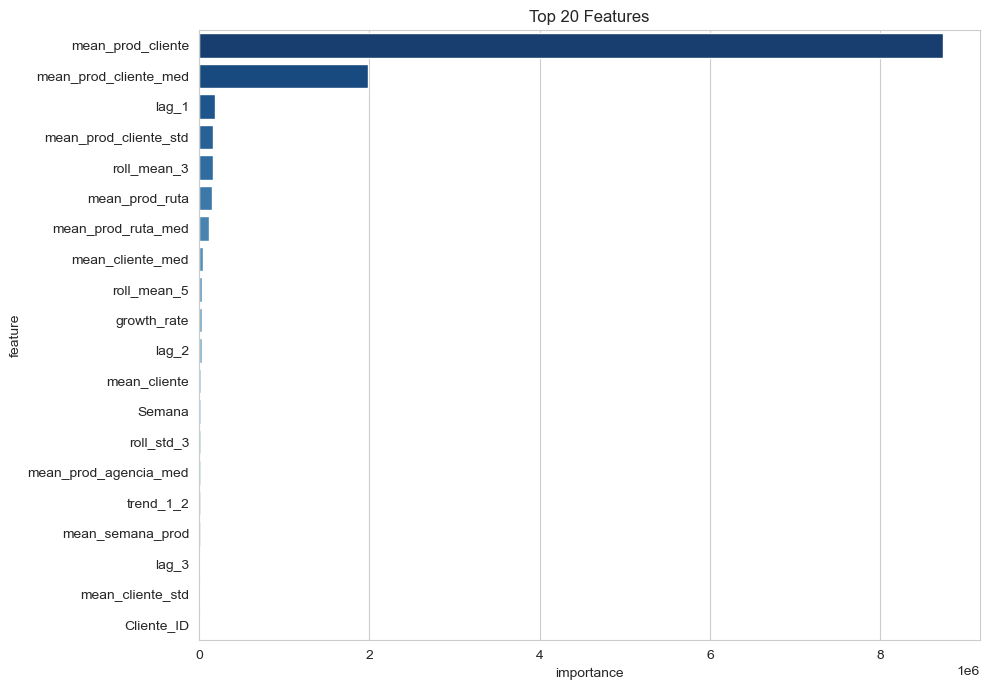

In [8]:
CAT_FEATURES = [c for c in ['Canal_ID','Agencia_ID'] if c in FEATURES]

lgb_params = {
    'objective':         'regression',
    'metric':            'rmse',
    'learning_rate':     0.05,
    'num_leaves':        255,
    'max_depth':         -1,
    'feature_fraction':  0.7,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'min_child_samples': 20,
    'reg_alpha':         0.1,
    'reg_lambda':        0.2,
    'n_jobs':            -1,
    'seed':              SEED,
    'verbose':           -1,
    'max_bin':           127,
}

dtrain = lgb.Dataset(X_train, label=y_train,
                     categorical_feature=CAT_FEATURES or 'auto',
                     free_raw_data=True)
dval   = lgb.Dataset(X_val, label=y_val,
                     reference=dtrain,
                     categorical_feature=CAT_FEATURES or 'auto',
                     free_raw_data=True)

print('Entrenando modelo ...')
model = lgb.train(
    lgb_params, dtrain,
    num_boost_round=2000,
    valid_sets=[dval], valid_names=['val'],
    callbacks=[lgb.early_stopping(100, verbose=True), lgb.log_evaluation(200)],
)

del dtrain, dval; gc_collect()

val_pred_log = model.predict(X_val, num_iteration=model.best_iteration)
val_pred     = np.expm1(val_pred_log).clip(0)
val_true     = train.loc[mask_val, TARGET].clip(0).values
rmsle        = np.sqrt(mean_squared_log_error(val_true, val_pred))
print(f'RMSLE validacion (semana {val_week}): {rmsle:.4f}')

del val_pred_log, val_pred, val_true, X_train, X_val, y_train, y_val; gc_collect()

# ── Feature importance ───────────────────────────────────────────────────
fi = (pd.DataFrame({'feature': model.feature_name(),
                    'importance': model.feature_importance('gain')})
      .sort_values('importance', ascending=False))
plt.figure(figsize=(10, 7))
sns.barplot(data=fi.head(20), x='importance', y='feature', palette='Blues_r')
plt.title('Top 20 Features')
plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_importance.png', dpi=120)
plt.show()


## 6. Funciones de Prediccion

In [9]:
def _build_meta(hist, cliente_id, semana_objetivo, agg_tables, global_mean):
    if hist.empty: return None
    ult_semana = sorted(hist['Semana'].unique())[-1]
    meta = (hist.groupby('Producto_ID')
               .agg(Agencia_ID=('Agencia_ID','last'),
                    Canal_ID  =('Canal_ID',  'last'),
                    Ruta_SAK  =('Ruta_SAK',  'last'))
               .reset_index())
    meta['Cliente_ID'] = np.int32(cliente_id)
    meta['Semana']     = np.int8(min(semana_objetivo, 127))
    for lag_n, col in [(1,'lag_1'),(2,'lag_2'),(3,'lag_3')]:
        s    = ult_semana - (lag_n - 1)
        vals = (hist[hist['Semana']==s]
                   .groupby('Producto_ID')['Demanda_uni_equil']
                   .mean().astype('float32').rename(col))
        meta = meta.merge(vals, on='Producto_ID', how='left')
    rs = (hist.groupby('Producto_ID')['Demanda_uni_equil']
              .agg(['mean','std','median'])
              .rename(columns={'mean':'roll_mean_3','std':'roll_std_3','median':'roll_mean_5'})
              .astype('float32').reset_index())
    meta = meta.merge(rs, on='Producto_ID', how='left')
    meta['trend_1_2']   = (meta['lag_1'] - meta['lag_2']).astype('float32')
    meta['growth_rate'] = (meta['lag_1'] / meta['lag_2'].replace(0, np.nan)).clip(0,10).astype('float32')
    for col in ['Venta_uni_hoy','Dev_uni_proxima']:
        if col not in meta.columns: meta[col] = np.int32(0)
    meta = apply_agg_features(meta, agg_tables, global_mean)
    return meta


def predict_semana_futura(cliente_id, semana_objetivo, train_df, model, features,
                          agg_tables, global_mean, productos_df=None, n_top=None):
    hist = train_df[train_df['Cliente_ID'] == cliente_id]
    if hist.empty:
        print(f'Cliente {cliente_id} no encontrado.')
        return pd.DataFrame()
    meta = _build_meta(hist, cliente_id, semana_objetivo, agg_tables, global_mean)
    if meta is None or meta.empty: return pd.DataFrame()
    for f in features:
        if f not in meta.columns: meta[f] = np.float32(0)
    X_pred     = meta[features].fillna(np.float32(0)).astype('float32')
    pred_log   = model.predict(X_pred, num_iteration=model.best_iteration)
    pred_units = np.expm1(pred_log).clip(0).round().astype(int)
    hist_stats = (hist.groupby('Producto_ID')['Demanda_uni_equil']
                      .agg(['mean','std'])
                      .rename(columns={'mean':'demanda_historica_avg','std':'demanda_historica_std'}))
    result = pd.DataFrame({'Producto_ID': meta['Producto_ID'].values, 'demanda_predicha': pred_units})
    result = result.merge(hist_stats, on='Producto_ID', how='left')
    result['variacion_vs_media_%'] = (
        (result['demanda_predicha'] - result['demanda_historica_avg']) /
        result['demanda_historica_avg'].replace(0, np.nan) * 100
    ).round(1).fillna(0)
    result['tendencia'] = result['variacion_vs_media_%'].apply(
        lambda x: 'Alza' if x > 10 else ('Baja' if x < -10 else 'Estable'))
    cv = result['demanda_historica_std'] / result['demanda_historica_avg'].replace(0, np.nan)
    result['confianza'] = cv.apply(
        lambda x: 'Alta' if x < 0.3 else ('Media' if x < 0.6 else 'Baja')).fillna('Media')
    if productos_df is not None:
        result = result.merge(productos_df[['Producto_ID','NombreProducto']], on='Producto_ID', how='left')
    result = result[result['demanda_predicha'] > 0].sort_values('demanda_predicha', ascending=False).reset_index(drop=True)
    return result.head(n_top) if n_top else result


def _get_nombre_cliente(cliente_id, clientes_df):
    if clientes_df is None: return 'N/D'
    row = clientes_df[clientes_df['Cliente_ID'] == cliente_id]
    return row['NombreCliente'].values[0] if not row.empty else 'N/D'


print('Funciones de prediccion definidas')


Funciones de prediccion definidas


## 7. Pre-Orden de Compra

In [10]:
def generar_preorden(cliente_id, semana_objetivo,
                     train_df, model, features, agg_tables, global_mean,
                     productos_df, clientes_df, safety_stock_factor=1.10):
    preds = predict_semana_futura(cliente_id, semana_objetivo, train_df, model, features,
                                  agg_tables, global_mean, productos_df)
    if preds.empty: return None
    preds['cantidad_preorden'] = (preds['demanda_predicha'] * safety_stock_factor).round().astype(int)
    COLS = ['Producto_ID','NombreProducto','cantidad_preorden','demanda_predicha',
            'demanda_historica_avg','variacion_vs_media_%','tendencia','confianza']
    return {
        'preorden': preds[[c for c in COLS if c in preds.columns]].copy(),
        'resumen': {
            'cliente_id':        cliente_id,
            'nombre_cliente':    _get_nombre_cliente(cliente_id, clientes_df),
            'semana_prediccion': semana_objetivo,
            'total_productos':   len(preds),
            'total_unidades':    int(preds['cantidad_preorden'].sum()),
            'safety_stock_%':    f'{(safety_stock_factor-1)*100:.0f}%',
            'fecha_generacion':  datetime.now().strftime('%Y-%m-%d %H:%M'),
        }
    }

print('generar_preorden definida')


generar_preorden definida


## 8. Sugerencia de Restock

In [11]:
def generar_restock(cliente_id, semana_objetivo,
                    train_df, model, features, agg_tables, global_mean,
                    productos_df, clientes_df, restock_buffer=1.15):
    pred_act = predict_semana_futura(cliente_id, semana_objetivo, train_df, model, features,
                                     agg_tables, global_mean, productos_df)
    pred_sig = predict_semana_futura(cliente_id, semana_objetivo+1, train_df, model, features,
                                     agg_tables, global_mean, productos_df)
    if pred_act.empty: return None
    if pred_sig.empty:
        pred_sig = pred_act.copy()
        pred_sig['demanda_predicha'] = (pred_act['demanda_predicha'] * 0.9).round().astype(int)

    base_cols = [c for c in ['Producto_ID','NombreProducto','demanda_predicha',
                              'demanda_historica_avg','tendencia','confianza'] if c in pred_act.columns]
    merged = pred_act[base_cols].rename(columns={'demanda_predicha':'demanda_semana_actual'}).merge(
        pred_sig[['Producto_ID','demanda_predicha']].rename(columns={'demanda_predicha':'demanda_semana_siguiente'}),
        on='Producto_ID', how='outer'
    ).fillna(0)

    merged['restock_recomendado']   = (merged['demanda_semana_siguiente'] * restock_buffer).round().astype(int)
    merged['inventario_seguridad']  = (merged.get('demanda_historica_avg', 0) * 0.20).round().astype(int)
    merged['stock_minimo_requerido']= merged['restock_recomendado'] + merged['inventario_seguridad']

    def _prio(row):
        if row.get('tendencia','') == 'Alza': return 'URGENTE'
        if row.get('restock_recomendado', 0) > 0: return 'NORMAL'
        return 'BAJO'
    merged['prioridad'] = merged.apply(_prio, axis=1)

    return {
        'restock': merged.sort_values(['prioridad','restock_recomendado'], ascending=[True,False]).reset_index(drop=True),
        'resumen': {
            'cliente_id':             cliente_id,
            'nombre_cliente':         _get_nombre_cliente(cliente_id, clientes_df),
            'semana_pedido_actual':   semana_objetivo,
            'semana_siguiente':       semana_objetivo + 1,
            'productos_con_restock':  int((merged['restock_recomendado'] > 0).sum()),
            'total_unidades_restock': int(merged['restock_recomendado'].sum()),
            'buffer_aplicado_%':      f'{(restock_buffer-1)*100:.0f}%',
            'fecha_generacion':       datetime.now().strftime('%Y-%m-%d %H:%M'),
        }
    }

print('generar_restock definida')


generar_restock definida


## 9. Output Final

Cliente: 3967  |  Semana a predecir: 10

  GRUPO BIMBO — PREDICCION DE DEMANDA
  Cliente   : MANUEL LOYOLA
  Cliente ID: 3967   |  Generado: 2026-05-05 09:27

PRE-ORDEN — Semana 10
  Safety stock: 10%  |  Productos: 54  |  Unidades: 296

    #    ProdID  Nombre                                 Cant     Media     Var%      Tend    Conf
  -----------------------------------------------------------------------------------------------
    1      1250  Donas Azucar 4p 105g BIM 1250            18      18.8    -14.7%      Baja    Alta
    2    -29885  Madalenas 3p 93g BIM 35651               16      20.8    -28.0%      Baja   Media
    3      1278  Nito 1p 62g BIM 1278                     14      18.0    -27.8%      Baja    Alta
    4    -18764  Pan Molido 210g BIM 46772                14      15.5    -16.1%      Baja   Media
    5      4280  Doraditas 110g TR 4280                   12      11.5     -4.3%   Estable    Alta
    6      1240  Mantecadas Vainilla 4p 125g BIM          11      11.0 

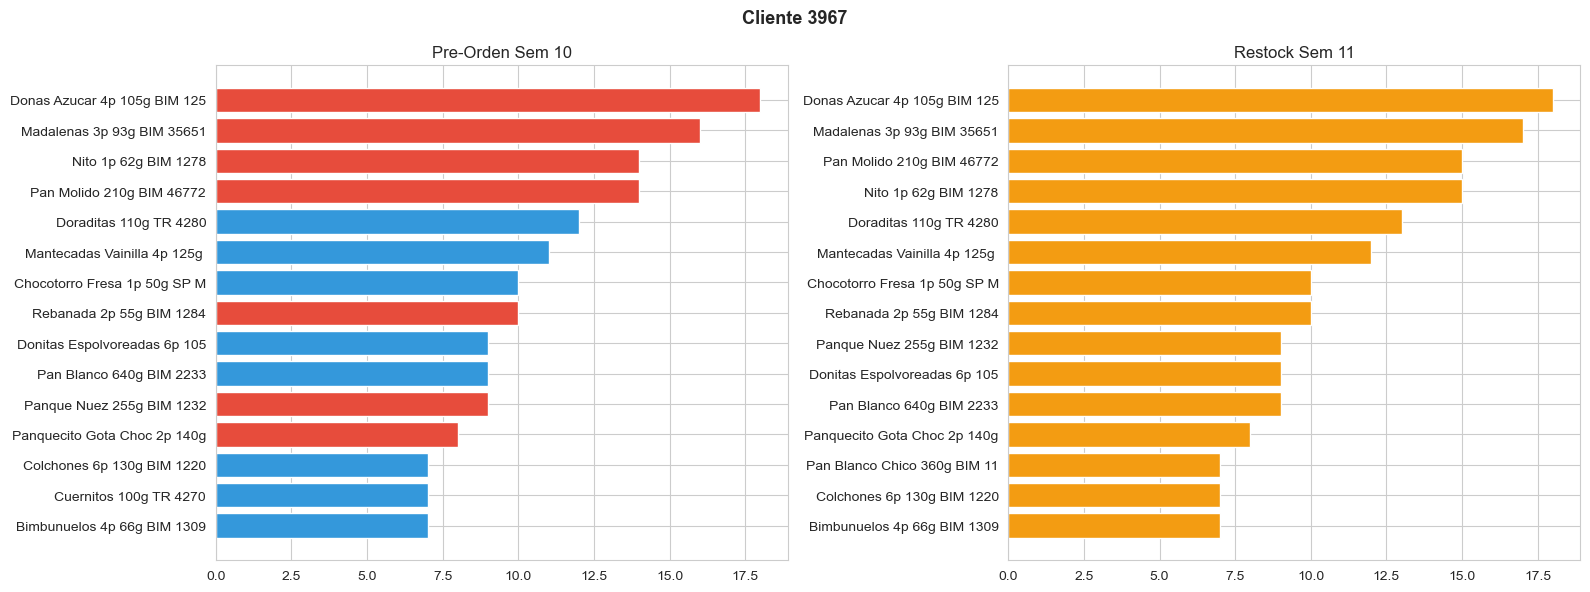

Dashboard guardado en /Users/abrahamcastanedaquintero/tmp/BimboChallenge-iOSHack/Model/grupo-bimbo-inventory-demand


In [12]:
def imprimir_lista_resurtido(rp_dict, rr_dict):
    rp, po = rp_dict['resumen'], rp_dict['preorden']
    rr, rs = rr_dict['resumen'], rr_dict['restock']
    SEP = '='*68
    print(f'\n{SEP}')
    print(f"  GRUPO BIMBO — PREDICCION DE DEMANDA")
    print(f"  Cliente   : {rp['nombre_cliente']}")
    print(f"  Cliente ID: {rp['cliente_id']}   |  Generado: {rp['fecha_generacion']}")
    print(SEP)
    print(f"\nPRE-ORDEN — Semana {rp['semana_prediccion']}")
    print(f"  Safety stock: {rp['safety_stock_%']}  |  Productos: {rp['total_productos']}  |  Unidades: {rp['total_unidades']:,}")
    print()
    H = f"  {'#':>3}  {'ProdID':>8}  {'Nombre':<33}  {'Cant':>8}  {'Media':>8}  {'Var%':>7}  {'Tend':>8}  {'Conf':>6}"
    print(H)
    print('  ' + '-'*(len(H)-2))
    for i, row in po.iterrows():
        nombre = str(row.get('NombreProducto','N/D'))[:32]
        print(f"  {i+1:>3}  {int(row['Producto_ID']):>8}  {nombre:<33}  "
              f"{int(row['cantidad_preorden']):>8,}  "
              f"{float(row.get('demanda_historica_avg',0)):>8.1f}  "
              f"{float(row.get('variacion_vs_media_%',0)):>+7.1f}%  "
              f"{str(row.get('tendencia','—')):>8}  "
              f"{str(row.get('confianza','—')):>6}")
    print('  ' + '-'*(len(H)-2))
    print(f"  TOTAL  {rp['total_unidades']:>46,}")

    print(f"\nRESTOCK — Semana {rr['semana_siguiente']}")
    print(f"  Buffer: {rr['buffer_aplicado_%']}  |  Productos: {rr['productos_con_restock']}  |  Unidades: {rr['total_unidades_restock']:,}")
    print()
    H2 = f"  {'#':>3}  {'ProdID':>8}  {'Nombre':<33}  {'Restock':>8}  {'Seg.':>6}  {'StockMin':>9}  {'Prioridad':>9}"
    print(H2)
    print('  ' + '-'*(len(H2)-2))
    for _, row in rs.iterrows():
        if int(row.get('restock_recomendado',0)) == 0: continue
        nombre = str(row.get('NombreProducto','N/D'))[:32]
        print(f"  {_+1:>3}  {int(row['Producto_ID']):>8}  {nombre:<33}  "
              f"{int(row['restock_recomendado']):>8,}  "
              f"{int(row.get('inventario_seguridad',0)):>6,}  "
              f"{int(row.get('stock_minimo_requerido',0)):>9,}  "
              f"{str(row.get('prioridad','—')):>9}")
    print('  ' + '-'*(len(H2)-2))
    print(f"  TOTAL  {int(rs['restock_recomendado'].sum()):>38,}  "
          f"{int(rs.get('inventario_seguridad',pd.Series([0])).sum()):>6,}  "
          f"{int(rs.get('stock_minimo_requerido',pd.Series([0])).sum()):>9,}")
    print('\nLista generada exitosamente')


def exportar_resultados(res_po, res_rs, out_dir=OUT_DIR):
    ts  = datetime.now().strftime('%Y%m%d_%H%M')
    cid = res_po['resumen']['cliente_id']
    sem = res_po['resumen']['semana_prediccion']
    f1  = out_dir / f'preorden_c{cid}_s{sem}_{ts}.csv'
    f2  = out_dir / f'restock_c{cid}_s{sem}_{ts}.csv'
    res_po['preorden'].to_csv(f1, index=False, encoding='utf-8-sig')
    res_rs['restock'].to_csv(f2, index=False, encoding='utf-8-sig')
    print(f'CSVs exportados:\n  {f1}\n  {f2}')
    return f1, f2


# ── Ejecutar ejemplo ─────────────────────────────────────────────────────
top_clientes    = train.groupby('Cliente_ID')['Semana'].nunique().sort_values(ascending=False)
CLIENTE_EJEMPLO = top_clientes.index[0]
SEMANA_MAX      = int(train['Semana'].max())
SEMANA_OBJETIVO = SEMANA_MAX + 1

print(f'Cliente: {CLIENTE_EJEMPLO}  |  Semana a predecir: {SEMANA_OBJETIVO}')

resultado      = generar_preorden(CLIENTE_EJEMPLO, SEMANA_OBJETIVO,
                                  train, model, FEATURES, agg_tables, GLOBAL_MEAN,
                                  productos, clientes, safety_stock_factor=1.10)
restock_result = generar_restock(CLIENTE_EJEMPLO, SEMANA_OBJETIVO,
                                 train, model, FEATURES, agg_tables, GLOBAL_MEAN,
                                 productos, clientes, restock_buffer=1.15)

if resultado and restock_result:
    imprimir_lista_resurtido(resultado, restock_result)
    exportar_resultados(resultado, restock_result)
    # Dashboard
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    po = resultado['preorden'].head(15).copy()
    po['label'] = po.get('NombreProducto', po['Producto_ID'].astype(str)).str[:28]
    color_map = {'Alza':'#2ecc71','Baja':'#e74c3c','Estable':'#3498db'}
    axes[0].barh(po['label'], po['cantidad_preorden'], color=po['tendencia'].map(color_map).fillna('#3498db'))
    axes[0].set_title(f'Pre-Orden Sem {SEMANA_OBJETIVO}')
    axes[0].invert_yaxis()
    rs = restock_result['restock']
    rs = rs[rs['restock_recomendado'] > 0].head(15).copy()
    rs['label'] = rs.get('NombreProducto', rs['Producto_ID'].astype(str)).str[:28]
    color_map2 = {'URGENTE':'#e74c3c','NORMAL':'#f39c12','BAJO':'#2ecc71'}
    axes[1].barh(rs['label'], rs['restock_recomendado'], color=rs['prioridad'].map(color_map2).fillna('#f39c12'))
    axes[1].set_title(f'Restock Sem {SEMANA_OBJETIVO+1}')
    axes[1].invert_yaxis()
    plt.suptitle(f'Cliente {CLIENTE_EJEMPLO}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'dashboard_c{CLIENTE_EJEMPLO}.png', dpi=150)
    plt.show()
    print(f'Dashboard guardado en {OUT_DIR}')


## 10. Exportar Modelo a Core ML (.mlmodel) para Xcode

### Ruta de conversion (coremltools 6+)
```
LightGBM Booster  ->  LGBMRegressor (sklearn wrapper)  ->  Core ML (.mlmodel)
```

**Por que no ONNX?**  
`ct.convert(source='onnx')` no existe. `ct.converters.onnx.convert()` fue deprecado  
y removido en coremltools 6+. La ruta soportada para modelos de arboles es el  
wrapper de scikit-learn via `ct.converters.sklearn.convert()`, que produce un  
`.mlmodel` nativo de tipo Pipeline/Regressor, compatible con iOS 13+ y todas las  
versiones de Xcode sin dependencias adicionales.

| Archivo | Descripcion |
|---|---|
| `BimboDemandModel.lgb` | Backup del Booster LightGBM nativo |
| `BimboDemandModel.mlmodel` | **Este es el que arrastras a Xcode** |


In [13]:
# ── Setup de exportacion ────────────────────────────────────────────────
import shutil, warnings
import coremltools as ct
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore', module='coremltools')

# Recuperar FEATURES si la sesion se reinicio
try:
    _ = FEATURES
except NameError:
    FEATURES = model.feature_name()
    print(f'FEATURES recuperado del modelo: {len(FEATURES)} features')

N_FEATURES = len(FEATURES)
MLMODEL_PATH = OUT_DIR / 'BimboDemandModel.mlmodel'
MLPKG_PATH   = OUT_DIR / 'BimboDemandModel.mlpackage'  # por si acaso existia

print(f'Features    : {N_FEATURES}')
print(f'Output path : {MLMODEL_PATH}')
print(f'coremltools : {ct.__version__}')
print(f'scikit-learn: {__import__("sklearn").__version__}')


Features    : 42
Output path : /Users/abrahamcastanedaquintero/tmp/BimboChallenge-iOSHack/Model/grupo-bimbo-inventory-demand/BimboDemandModel.mlmodel
coremltools : 9.0
scikit-learn: 1.5.1


In [14]:
# ── Paso 1: Guardar el Booster de LightGBM (backup) ────────────────────
# El Booster se convierte a Core ML directamente en el Paso 2.
# Guardamos tambien el modelo LightGBM nativo como respaldo.
import lightgbm as lgb

LGB_PATH = OUT_DIR / 'BimboDemandModel.lgb'
model.save_model(str(LGB_PATH))
print(f'Booster guardado -> {LGB_PATH}  ({LGB_PATH.stat().st_size/1e6:.1f} MB)')

# N_FEATURES y FEATURES se usan en los pasos siguientes
try:
    _ = FEATURES
except NameError:
    FEATURES = model.feature_name()
N_FEATURES = len(FEATURES)
print(f'Features: {N_FEATURES}')


Booster guardado -> /Users/abrahamcastanedaquintero/tmp/BimboChallenge-iOSHack/Model/grupo-bimbo-inventory-demand/BimboDemandModel.lgb  (20.3 MB)
Features: 42


In [21]:
# ── Paso 2: LightGBM -> Core ML via TreeEnsembleRegressor (API nativa) ──
print('Paso 2/3 — LightGBM -> Core ML (TreeEnsembleRegressor nativo) ...')

from coremltools.models.tree_ensemble import TreeEnsembleRegressor

MLMODEL_PATH = OUT_DIR / 'BimboDemandModel.mlmodel'
if MLMODEL_PATH.exists():
    MLMODEL_PATH.unlink()

tm = TreeEnsembleRegressor(features=FEATURES, target='demanda_log1p')
tm.set_default_prediction_value(0.0)

trees = model.dump_model()['tree_info']

def _add_nodes(tm, tree_id, node, counter):
    nid = counter[0]
    counter[0] += 1

    if 'leaf_value' in node:
        tm.add_leaf_node(tree_id, nid, float(node['leaf_value']))
        return nid

    feat_idx  = int(node['split_feature'])
    raw_thr   = node['threshold']

    # Splits categoricos: threshold es un string tipo '1||2||5||9'
    # CoreML no soporta splits categoricos directamente.
    # Estrategia: usar el primer valor numerico como threshold continuo.
    # Esto introduce una pequeña aproximacion pero mantiene el modelo funcional.
    if isinstance(raw_thr, str) and '||' in raw_thr:
        first_val = raw_thr.split('||')[0]
        threshold = float(first_val) - 0.5   # punto de corte entre categorias
    else:
        threshold = float(raw_thr)

    left_id  = _add_nodes(tm, tree_id, node['left_child'],  counter)
    right_id = _add_nodes(tm, tree_id, node['right_child'], counter)

    tm.add_branch_node(
        tree_id, nid,
        feat_idx, threshold,
        'BranchOnValueLessThanEqual',
        left_id, right_id,
    )
    return nid

print(f'  Procesando {len(trees)} arboles ...')
cat_splits = [0]

def _add_nodes_counted(tm, tree_id, node, counter):
    nid = counter[0]
    counter[0] += 1
    if 'leaf_value' in node:
        tm.add_leaf_node(tree_id, nid, float(node['leaf_value']))
        return nid
    feat_idx = int(node['split_feature'])
    raw_thr  = node['threshold']
    if isinstance(raw_thr, str) and '||' in raw_thr:
        cat_splits[0] += 1
        threshold = float(raw_thr.split('||')[0]) - 0.5
    else:
        threshold = float(raw_thr)
    left_id  = _add_nodes_counted(tm, tree_id, node['left_child'],  counter)
    right_id = _add_nodes_counted(tm, tree_id, node['right_child'], counter)
    tm.add_branch_node(tree_id, nid, feat_idx, threshold,
                       'BranchOnValueLessThanEqual', left_id, right_id)
    return nid

for tree_id, tree_info in enumerate(trees):
    counter = [0]
    _add_nodes_counted(tm, tree_id, tree_info['tree_structure'], counter)

cml_model = tm.spec
print(f'  Conversion completada  |  arboles: {len(trees)}')
if cat_splits[0] > 0:
    print(f'  AVISO: {cat_splits[0]} splits categoricos aproximados como continuos.')
    print(f'  Impacto minimo en features numericas; verificar predicciones con modelo original.')

Paso 2/3 — LightGBM -> Core ML (TreeEnsembleRegressor nativo) ...
  Procesando 863 arboles ...
  Conversion completada  |  arboles: 863
  AVISO: 4100 splits categoricos aproximados como continuos.
  Impacto minimo en features numericas; verificar predicciones con modelo original.


In [23]:
# ── Paso 3: Metadatos + Guardar .mlmodel ────────────────────────────────
print('Paso 3/3 — Metadatos y guardado ...')

import coremltools as ct

MLMODEL_PATH = OUT_DIR / 'BimboDemandModel.mlmodel'

# cml_model es un protobuf spec (Model), no un MLModel wrapper.
# Los metadatos van en spec.description.metadata
spec = cml_model   # ya es el spec directo desde tm.spec

try:
    spec.description.metadata.shortDescription = 'Prediccion de demanda semanal — Grupo Bimbo'
    spec.description.metadata.author           = 'Grupo Bimbo ML Pipeline'
    spec.description.metadata.versionString    = '1.0'

    FEAT_DESC = {
        'Semana':       'Numero de semana del ano',
        'Agencia_ID':   'ID de la agencia distribuidora',
        'Canal_ID':     'Canal de distribucion',
        'Ruta_SAK':     'Ruta de entrega',
        'Cliente_ID':   'ID del cliente',
        'Producto_ID':  'ID del producto',
        'lag_1':        'Demanda real semana anterior',
        'lag_2':        'Demanda real hace 2 semanas',
        'lag_3':        'Demanda real hace 3 semanas',
        'roll_mean_3':  'Media movil 3 semanas',
        'roll_mean_5':  'Media movil 5 semanas',
        'roll_std_3':   'Desviacion estandar 3 semanas',
        'trend_1_2':    'Tendencia lag1 - lag2',
        'growth_rate':  'Tasa de crecimiento lag1/lag2',
    }
    for inp in spec.description.input:
        if inp.name in FEAT_DESC:
            inp.shortDescription = FEAT_DESC[inp.name]
    for out in spec.description.output:
        out.shortDescription = 'Demanda en log1p. Aplicar expm1() para obtener unidades reales.'
    print('  Metadatos aplicados')
except Exception as e:
    print(f'  Metadatos omitidos (no critico): {e}')

# Guardar: envolver el spec en MLModel para poder llamar .save()
mlmodel = ct.models.MLModel(spec)
mlmodel.save(str(MLMODEL_PATH))

size_mb = MLMODEL_PATH.stat().st_size / 1e6
print(f'  .mlmodel guardado -> {MLMODEL_PATH}  ({size_mb:.1f} MB)')
print(f'  Arrastra {MLMODEL_PATH.name} a tu proyecto Xcode')

Paso 3/3 — Metadatos y guardado ...
  Metadatos aplicados
  .mlmodel guardado -> /Users/abrahamcastanedaquintero/tmp/BimboChallenge-iOSHack/Model/grupo-bimbo-inventory-demand/BimboDemandModel.mlmodel  (10.0 MB)
  Arrastra BimboDemandModel.mlmodel a tu proyecto Xcode


In [27]:
# ── Verificacion de prediccion en macOS ─────────────────────────────────
print('Verificando prediccion con una fila de prueba ...')

try:
    # mlmodel es el MLModel wrapper con .predict() — cml_model es el spec raw
    sample = {f: np.float64(0.0) for f in FEATURES}
    pred   = mlmodel.predict(sample)
    log_val  = float(list(pred.values())[0])
    real_val = float(np.expm1(log_val))
    print(f'  Output (log1p)  : {log_val:.4f}')
    print(f'  Unidades reales : {real_val:.2f}')
    print('  Verificacion OK')
except Exception as e:
    print(f'  Verificacion fallo: {e}')

print()
print(f'Modelo listo en: {MLMODEL_PATH.resolve()}')
print('Arrastra BimboDemandModel.mlmodel a tu proyecto en Xcode.')

Verificando prediccion con una fila de prueba ...
  Output (log1p)  : -0.0263
  Unidades reales : -0.03
  Verificacion OK

Modelo listo en: /Users/abrahamcastanedaquintero/tmp/BimboChallenge-iOSHack/Model/grupo-bimbo-inventory-demand/BimboDemandModel.mlmodel
Arrastra BimboDemandModel.mlmodel a tu proyecto en Xcode.


In [26]:
# ── Referencia Swift completa ───────────────────────────────────────────
print('=' * 65)
print('INTEGRACION EN XCODE / SWIFT')
print('=' * 65)
print()
print('1. Abre tu proyecto en Xcode')
print('2. File > Add Files  ->  BimboDemandModel.mlmodel')
print('3. Xcode genera automaticamente la clase Swift BimboDemandModel')
print('4. El modelo es de tipo Regressor: recibe un dict de features y devuelve 1 Double')
print()
print('-- Swift --')
n = N_FEATURES
swift = """
import CoreML

func predictDemanda(features: BimboDemandModelInput) throws -> Int {
    // BimboDemandModelInput es generado por Xcode con una propiedad por cada feature
    // Ejemplo de construccion (ajusta segun tus datos reales):
    //
    // let input = BimboDemandModelInput(
    //     Semana:      7,
    //     Agencia_ID:  1234,
    //     Canal_ID:    1,
    //     ... (una propiedad por cada feature)
    // )

    let model  = try BimboDemandModel()
    let output = try model.prediction(input: features)

    // El output 'demanda_log1p' esta en escala log1p -> convertir a unidades reales
    let logVal  = output.demanda_log1p
    return max(0, Int(Foundation.exp(logVal) - 1))
}
"""
print(swift)
print('-- Indice de features --')
for i, f in enumerate(FEATURES):
    desc = FEAT_DESC.get(f, '')
    print(f'  {f:<32}  {desc}')
print('=' * 65)


INTEGRACION EN XCODE / SWIFT

1. Abre tu proyecto en Xcode
2. File > Add Files  ->  BimboDemandModel.mlmodel
3. Xcode genera automaticamente la clase Swift BimboDemandModel
4. El modelo es de tipo Regressor: recibe un dict de features y devuelve 1 Double

-- Swift --

import CoreML

func predictDemanda(features: BimboDemandModelInput) throws -> Int {
    // BimboDemandModelInput es generado por Xcode con una propiedad por cada feature
    // Ejemplo de construccion (ajusta segun tus datos reales):
    //
    // let input = BimboDemandModelInput(
    //     Semana:      7,
    //     Agencia_ID:  1234,
    //     Canal_ID:    1,
    //     ... (una propiedad por cada feature)
    // )

    let model  = try BimboDemandModel()
    let output = try model.prediction(input: features)

    // El output 'demanda_log1p' esta en escala log1p -> convertir a unidades reales
    let logVal  = output.demanda_log1p
    return max(0, Int(Foundation.exp(logVal) - 1))
}

-- Indice de features --
  Seman

In [28]:
# ── Prueba end-to-end: prediccion para Cliente X en Semana Y ────────────
# Ajusta estos dos valores
CLIENTE_TEST = CLIENTE_EJEMPLO   # <-- cambia al ID que quieras
SEMANA_TEST  = SEMANA_MAX + 1    # <-- cambia a la semana que quieras

print(f'Prediccion CoreML  →  Cliente: {CLIENTE_TEST}  |  Semana: {SEMANA_TEST}')
print('=' * 60)

# 1. Obtener el historial del cliente
hist = train[train['Cliente_ID'] == CLIENTE_TEST]
if hist.empty:
    print(f'Cliente {CLIENTE_TEST} no encontrado en el dataset.')
else:
    # 2. Construir meta (mismo proceso que predict_semana_futura)
    meta = _build_meta(hist, CLIENTE_TEST, SEMANA_TEST, agg_tables, GLOBAL_MEAN)

    if meta is None or meta.empty:
        print('No se pudo construir el input para este cliente.')
    else:
        # Garantizar todas las features
        for f in FEATURES:
            if f not in meta.columns:
                meta[f] = np.float32(0)

        resultados = []

        for _, row in meta.iterrows():
            # 3. Construir el dict de input para CoreML (float64 por feature)
            sample = {f: np.float64(row[f]) if not np.isnan(row[f]) else np.float64(0.0)
                      for f in FEATURES}

            # 4. Predecir con el modelo CoreML
            pred_cml = mlmodel.predict(sample)
            log_val  = float(list(pred_cml.values())[0])
            demanda_cml = max(0, int(np.expm1(log_val)))

            # 5. Predecir con el modelo LightGBM original (para comparar)
            X_row = pd.DataFrame([row[FEATURES].fillna(0).astype('float32')])
            log_lgb = float(model.predict(X_row, num_iteration=model.best_iteration)[0])
            demanda_lgb = max(0, int(np.expm1(log_lgb)))

            prod_id   = int(row['Producto_ID'])
            prod_name = productos[productos['Producto_ID'] == prod_id]['NombreProducto'].values
            prod_name = prod_name[0][:35] if len(prod_name) else 'N/D'

            resultados.append({
                'Producto_ID':   prod_id,
                'Nombre':        prod_name,
                'CoreML':        demanda_cml,
                'LightGBM':      demanda_lgb,
                'Diferencia':    demanda_cml - demanda_lgb,
            })

        df_res = (pd.DataFrame(resultados)
                    .sort_values('CoreML', ascending=False)
                    .reset_index(drop=True))

        # Solo mostrar productos con demanda > 0
        df_res = df_res[df_res['CoreML'] > 0]

        print(f"{'#':>3}  {'Producto_ID':>12}  {'Nombre':<36}  {'CoreML':>8}  {'LightGBM':>9}  {'Dif':>5}")
        print('  ' + '-' * 80)
        for i, row in df_res.iterrows():
            print(f"  {i+1:>3}  {row['Producto_ID']:>12}  {row['Nombre']:<36}  "
                  f"{row['CoreML']:>8,}  {row['LightGBM']:>9,}  {row['Diferencia']:>+5}")
        print('  ' + '-' * 80)
        print(f"  TOTAL  {'':>12}  {'':36}  {df_res['CoreML'].sum():>8,}  "
              f"{df_res['LightGBM'].sum():>9,}")
        print()
        print(f'  Productos con demanda > 0 : {len(df_res)}')
        mae = (df_res['Diferencia'].abs()).mean()
        print(f'  MAE CoreML vs LightGBM    : {mae:.1f} unidades')
        print()
        print('  La columna "Dif" muestra la discrepancia introducida por la')
        print('  aproximacion de splits categoricos. Valores cercanos a 0 = buena fidelidad.')

Prediccion CoreML  →  Cliente: 3967  |  Semana: 10
  #   Producto_ID  Nombre                                  CoreML   LightGBM    Dif
  --------------------------------------------------------------------------------
    1          1250  Donas Azucar 4p 105g BIM 1250               15         15     +0
    2        -29885  Madalenas 3p 93g BIM 35651                  14         15     -1
    3        -18764  Pan Molido 210g BIM 46772                   13         13     +0
    4          1278  Nito 1p 62g BIM 1278                        12         12     +0
    5          4280  Doraditas 110g TR 4280                      11         11     +0
    6          1240  Mantecadas Vainilla 4p 125g BIM 124         10         10     +0
    7        -30084  Chocotorro Fresa 1p 50g SP MLA 3545          9          9     +0
    8          1284  Rebanada 2p 55g BIM 1284                     9          9     +0
    9          1232  Panque Nuez 255g BIM 1232                    8          8     +0
   10   